In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d
plt.style.use('_mpl-gallery')
pd.set_option("display.precision", 4)

s11 = pd.read_csv('data/med1.csv')
s12 = pd.read_csv('data/med1_no.csv')
s11mean = s11.groupby(['N', 'P'])[['MSEA', 'MSEV']].mean().reset_index()
s12mean = s12.groupby(['N', 'P'])[['MSEA', 'MSEV']].mean().reset_index()
s11mean

,N,P,MSEA,MSEV
0,5000,5,0.1133,0.0217
1,5000,10,0.1141,0.0230
2,5000,20,0.1129,0.0347
3,5000,50,0.1125,0.0383
4,10000,5,0.0813,0.0192
5,10000,10,0.0813,0.0110
6,10000,20,0.0809,0.0226
7,10000,50,0.0818,0.0135
8,20000,5,0.0502,0.0042
9,20000,10,0.0502,0.0042


In [51]:
s12mean

,N,P,MSEA,MSEV
0,5000,5,0.3144,0.0973
1,5000,10,0.9331,0.7528
2,5000,20,1.9036,3.1338
3,5000,50,3.2565,9.9012
4,10000,5,0.2196,0.0489
5,10000,10,0.7475,0.4774
6,10000,20,1.6510,2.3455
7,10000,50,2.9914,8.2117
8,20000,5,0.1609,0.0229
9,20000,10,0.5931,0.2771


In [52]:
p5_1 = s11mean.loc[s11mean['P'] == 5, ['N', 'MSEA', 'MSEV']].reset_index(drop=True)
p10_1 = s11mean.loc[s11mean['P'] == 10, ['MSEA', 'MSEV']].reset_index(drop=True)
p20_1 = s11mean.loc[s11mean['P'] == 20, ['MSEA', 'MSEV']].reset_index(drop=True)
p50_1 = s11mean.loc[s11mean['P'] == 50, ['MSEA', 'MSEV']].reset_index(drop=True)

p5_2 = s12mean.loc[s12mean['P'] == 5, ['N', 'MSEA', 'MSEV']].reset_index(drop=True)
p10_2 = s12mean.loc[s12mean['P'] == 10, ['MSEA', 'MSEV']].reset_index(drop=True)
p20_2 = s12mean.loc[s12mean['P'] == 20, ['MSEA', 'MSEV']].reset_index(drop=True)
p50_2 = s12mean.loc[s12mean['P'] == 50, ['MSEA', 'MSEV']].reset_index(drop=True)

df1 = pd.concat([p5_1, p10_1, p20_1, p50_1], axis=1)
df1.index = pd.MultiIndex.from_tuples([
    ("FS", "1"), ("FS", "2"), ("FS", "3"), ("FS", "4"), ("FS", "5")
])

df2 = pd.concat([p5_2, p10_2, p20_2, p50_2], axis=1)
df2.index = pd.MultiIndex.from_tuples([
    ("NFS", "1"), ("NFS", "2"), ("NFS", "3"), ("NFS", "4"), ("FS", "5")
])

df = pd.concat([df1, df2], axis=0)
latex = df.style.format(precision=4).format_index(
    axis=1, formatter="${}$".format).hide(axis=0).to_latex(
        position='bt!',
        position_float="centering",
        hrules=False, 
        label="tab:med1", 
        column_format='c|c|cc|cc|cc|cc',
        caption="Performance evaluations in scenario 3 of the estimators $\overline{x}$ and $\hat{v}$ for the different K-NN graph settings described in the text with and without feature selection. We report the mean squared error averaging over 100 Monte Carlo simulations.",
)
print(latex)

\begin{table}[bt!]
\centering
\caption{Performance evaluations in scenario 3 of the estimators $\overline{x}$ and $\hat{v}$ for the different K-NN graph settings described in the text with and without feature selection. We report the mean squared error averaging over 100 Monte Carlo simulations.}
\label{tab:med1}
\begin{tabular}{c|c|cc|cc|cc|cc}
$N$ & $MSEA$ & $MSEV$ & $MSEA$ & $MSEV$ & $MSEA$ & $MSEV$ & $MSEA$ & $MSEV$ \\
5000 & 0.1133 & 0.0217 & 0.1141 & 0.0230 & 0.1129 & 0.0347 & 0.1125 & 0.0383 \\
10000 & 0.0813 & 0.0192 & 0.0813 & 0.0110 & 0.0809 & 0.0226 & 0.0818 & 0.0135 \\
20000 & 0.0502 & 0.0042 & 0.0502 & 0.0042 & 0.0499 & 0.0046 & 0.0501 & 0.0044 \\
50000 & 0.0316 & 0.0022 & 0.0316 & 0.0023 & 0.0315 & 0.0023 & 0.0316 & 0.0025 \\
100000 & 0.0205 & 0.0015 & 0.0205 & 0.0015 & 0.0206 & 0.0016 & 0.0205 & 0.0016 \\
5000 & 0.3144 & 0.0973 & 0.9331 & 0.7528 & 1.9036 & 3.1338 & 3.2565 & 9.9012 \\
10000 & 0.2196 & 0.0489 & 0.7475 & 0.4774 & 1.6510 & 2.3455 & 2.9914 & 8.2117 \\
20000 &

Text(0.5, 0, 'MSE ')

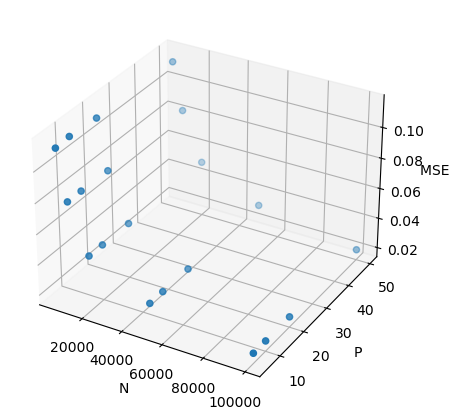

In [53]:
fig = plt.figure(figsize=(12, 4))  
ax = fig.add_subplot(projection='3d')
ax.scatter(s11mean.N, s11mean.P, s11mean.MSEA)
ax.set_xlabel('N')
ax.set_ylabel('P')
ax.set_zlabel('MSE ')
#ax.set_title('Simulation 1: 2 variables in mean - 0 variables in variance')

Text(0.5, 0, 'MSE ')

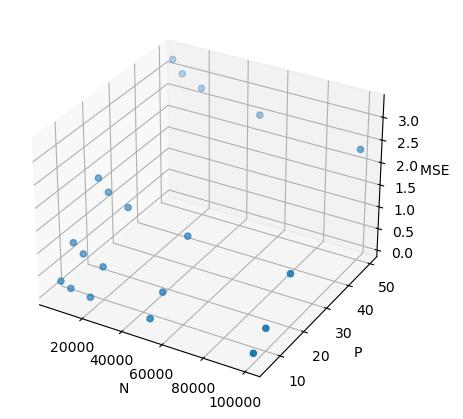

In [54]:
fig = plt.figure(figsize=(6, 4))  
ax = fig.add_subplot(projection='3d')
ax.scatter(s12mean.N, s12mean.P, s12mean.MSEA)
ax.set_xlabel('N')
ax.set_ylabel('P')
ax.set_zlabel('MSE ')
#ax.set_title('Simulation 1: 2 variables in mean - 0 variables in variance')

Text(0.5, 0, 'MSEV')

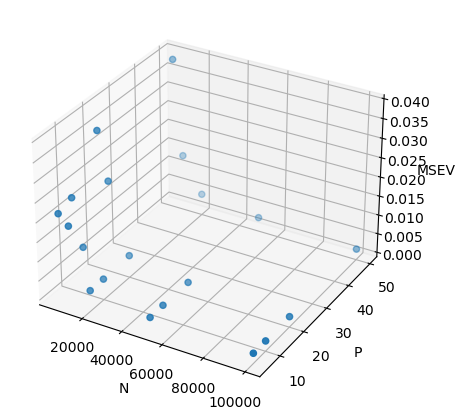

In [55]:
fig = plt.figure(figsize=(6, 4))  
ax = fig.add_subplot(projection='3d')
ax.scatter(s11mean.N, s11mean.P, s11mean.MSEV)
ax.set_xlabel('N')
ax.set_ylabel('P')
ax.set_zlabel('MSEV')
#ax.set_title('Simulation 1: 2 variables in mean - 0 variables in variance')

Text(0.5, 0, 'MSEV')

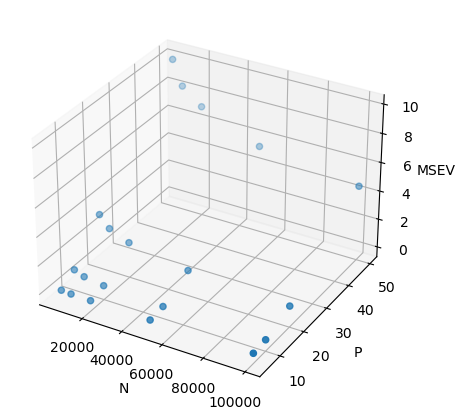

In [56]:
fig = plt.figure(figsize=(6, 4))  
ax = fig.add_subplot(projection='3d')
ax.scatter(s12mean.N, s12mean.P, s12mean.MSEV)
ax.set_xlabel('N')
ax.set_ylabel('P')
ax.set_zlabel('MSEV')
#ax.set_title('Simulation 1: 2 variables in mean - 0 variables in variance')

In [57]:
s21 = pd.read_csv('data/med2.csv')
s22 = pd.read_csv('data/med2_no.csv')
s21mean = s21.groupby(['N', 'P'])[['MSEA', 'MSEV']].mean().reset_index()
s22mean = s22.groupby(['N', 'P'])[['MSEA', 'MSEV']].mean().reset_index()
s21mean

,N,P,MSEA,MSEV
0,5000,5,0.0184,4.7813
1,5000,10,0.0159,5.2681
2,5000,20,0.0168,5.6835
3,5000,50,0.0168,6.0965
4,10000,5,0.0086,4.6833
5,10000,10,0.0107,4.7571
6,10000,20,0.0091,5.9863
7,10000,50,0.0090,5.5643
8,20000,5,0.0071,3.9487
9,20000,10,0.0063,4.3996


In [58]:
s22mean

,N,P,MSEA,MSEV
0,5000,5,0.0173,4.6294
1,5000,10,0.0159,5.1821
2,5000,20,0.0167,5.6338
3,5000,50,0.0169,6.0650
4,10000,5,0.0082,4.0516
5,10000,10,0.0106,4.5364
6,10000,20,0.0085,5.9468
7,10000,50,0.0090,5.5558
8,20000,5,0.0059,3.2773
9,20000,10,0.0063,4.0511


In [59]:
p5_1 = s21mean.loc[s21mean['P'] == 5, ['N', 'MSEA', 'MSEV']].reset_index(drop=True)
p10_1 = s21mean.loc[s21mean['P'] == 10, ['MSEA', 'MSEV']].reset_index(drop=True)
p20_1 = s21mean.loc[s21mean['P'] == 20, ['MSEA', 'MSEV']].reset_index(drop=True)
p50_1 = s21mean.loc[s21mean['P'] == 50, ['MSEA', 'MSEV']].reset_index(drop=True)

p5_2 = s22mean.loc[s22mean['P'] == 5, ['N', 'MSEA', 'MSEV']].reset_index(drop=True)
p10_2 = s22mean.loc[s22mean['P'] == 10, ['MSEA', 'MSEV']].reset_index(drop=True)
p20_2 = s22mean.loc[s22mean['P'] == 20, ['MSEA', 'MSEV']].reset_index(drop=True)
p50_2 = s22mean.loc[s22mean['P'] == 50, ['MSEA', 'MSEV']].reset_index(drop=True)

df1 = pd.concat([p5_1, p10_1, p20_1, p50_1], axis=1)
df1.index = pd.MultiIndex.from_tuples([
    ("FS", "1"), ("FS", "2"), ("FS", "3"), ("FS", "4"), ("FS", "5")
])

df2 = pd.concat([p5_2, p10_2, p20_2, p50_2], axis=1)
df2.index = pd.MultiIndex.from_tuples([
    ("FS", "1"), ("FS", "2"), ("FS", "3"), ("FS", "4"), ("FS", "5")
])

df = pd.concat([df1, df2], axis=0)
latex = df.style.format(precision=4).format_index(
    axis=1, formatter="${}$".format).hide(axis=0).to_latex(
        position='bt!',
        position_float="centering",
        hrules=False, 
        label="tab:med2", 
        column_format='c|c|cc|cc|cc|cc',
        caption="Performance evaluations in scenario 3 of the estimators $\overline{x}$ and $\hat{v}$ for the different K-NN graph settings described in the text with and without feature selection. We report the mean squared error averaging over 100 Monte Carlo simulations.",
)
print(latex)

\begin{table}[bt!]
\centering
\caption{Performance evaluations in scenario 3 of the estimators $\overline{x}$ and $\hat{v}$ for the different K-NN graph settings described in the text with and without feature selection. We report the mean squared error averaging over 100 Monte Carlo simulations.}
\label{tab:med2}
\begin{tabular}{c|c|cc|cc|cc|cc}
$N$ & $MSEA$ & $MSEV$ & $MSEA$ & $MSEV$ & $MSEA$ & $MSEV$ & $MSEA$ & $MSEV$ \\
5000 & 0.0184 & 4.7813 & 0.0159 & 5.2681 & 0.0168 & 5.6835 & 0.0168 & 6.0965 \\
10000 & 0.0086 & 4.6833 & 0.0107 & 4.7571 & 0.0091 & 5.9863 & 0.0090 & 5.5643 \\
20000 & 0.0071 & 3.9487 & 0.0063 & 4.3996 & 0.0055 & 4.5909 & 0.0060 & 5.0149 \\
50000 & 0.0294 & 2.2449 & 0.0092 & 2.0947 & 0.0094 & 2.3559 & 0.0091 & 2.4721 \\
100000 & 0.0090 & 0.6105 & 0.0116 & 0.5900 & 0.0064 & 0.6193 & 0.0115 & 0.8261 \\
5000 & 0.0173 & 4.6294 & 0.0159 & 5.1821 & 0.0167 & 5.6338 & 0.0169 & 6.0650 \\
10000 & 0.0082 & 4.0516 & 0.0106 & 4.5364 & 0.0085 & 5.9468 & 0.0090 & 5.5558 \\
20000 &

Text(0.5, 0, 'MSEA')

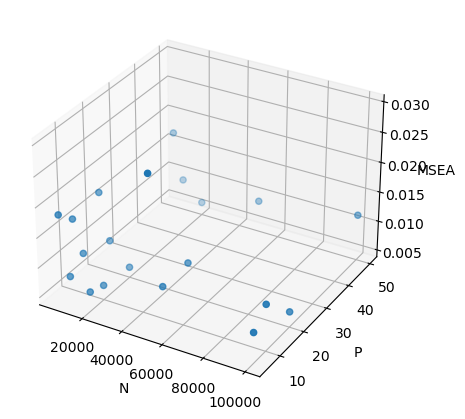

In [60]:
fig = plt.figure(figsize=(6, 4))  
ax = fig.add_subplot(projection='3d')
ax.scatter(s21mean.N, s21mean.P, s21mean.MSEA)
ax.set_xlabel('N')
ax.set_ylabel('P')
ax.set_zlabel('MSEA')
#ax.set_title('Simulation 2: 0 variables in mean - 1 variable in variance')

Text(0.5, 0, 'MSEA')

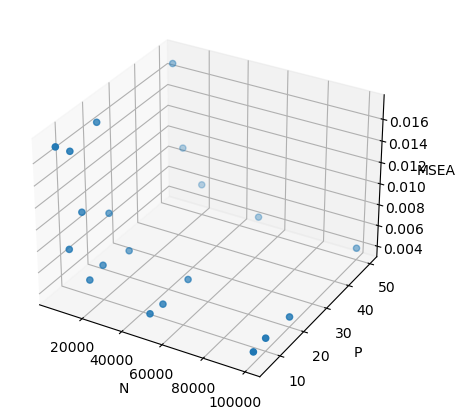

In [61]:
fig = plt.figure(figsize=(6, 4))  
ax = fig.add_subplot(projection='3d')
ax.scatter(s22mean.N, s22mean.P, s22mean.MSEA)
ax.set_xlabel('N')
ax.set_ylabel('P')
ax.set_zlabel('MSEA')
#ax.set_title('Simulation 2: 0 variables in mean - 1 variable in variance')

Text(0.5, 0, 'MSEV')

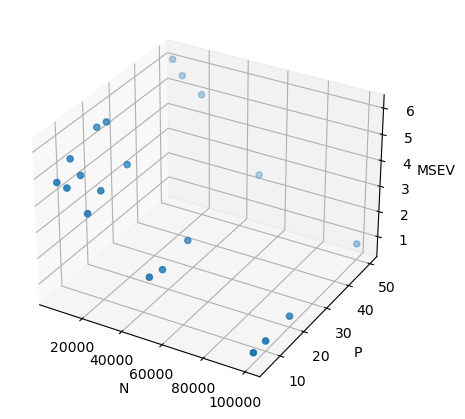

In [62]:
fig = plt.figure(figsize=(6, 4))  
ax = fig.add_subplot(projection='3d')
ax.scatter(s21mean.N, s21mean.P, s21mean.MSEV)
ax.set_xlabel('N')
ax.set_ylabel('P')
ax.set_zlabel('MSEV')
#ax.set_title('Simulation 2: 0 variables in mean - 1 variable in variance')

Text(0.5, 0, 'MSEV')

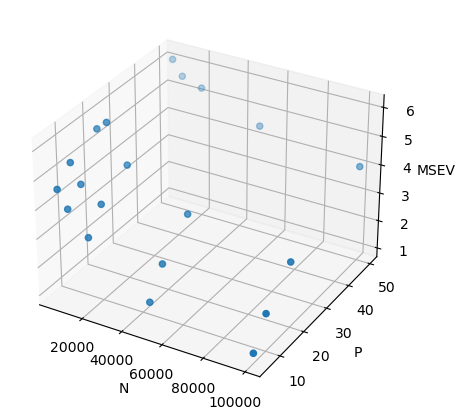

In [63]:
fig = plt.figure(figsize=(6, 4))  
ax = fig.add_subplot(projection='3d')
ax.scatter(s22mean.N, s22mean.P, s22mean.MSEV)
ax.set_xlabel('N')
ax.set_ylabel('P')
ax.set_zlabel('MSEV')
#ax.set_title('Simulation 2: 0 variables in mean - 1 variable in variance')

In [64]:
s31 = pd.read_csv('data/med3.csv')
s32 = pd.read_csv('data/med3_no.csv')
s31mean = s31.groupby(['N', 'P'])[['MSEA', 'MSEV']].mean().reset_index()
s32mean = s32.groupby(['N', 'P'])[['MSEA', 'MSEV']].mean().reset_index()
s31mean


,N,P,MSEA,MSEV
0,5000,5,0.1099,2.9097
1,5000,10,0.1097,4.4237
2,5000,20,0.1122,3.9644
3,5000,50,0.1313,3.9069
4,10000,5,0.0753,3.0066
5,10000,10,0.0730,2.9182
6,10000,20,0.0742,4.4914
7,10000,50,0.0751,3.2367
8,20000,5,0.0451,1.9320
9,20000,10,0.0443,1.8292


In [65]:
s32mean

,N,P,MSEA,MSEV
0,5000,5,0.3938,2.7810
1,5000,10,0.8619,3.7975
2,5000,20,1.5102,5.7212
3,5000,50,2.3795,14.4896
4,10000,5,0.2765,2.6488
5,10000,10,0.7041,3.1965
6,10000,20,1.3164,5.0554
7,10000,50,2.1878,8.8444
8,20000,5,0.2127,2.1886
9,20000,10,0.5547,2.8820


In [66]:
p5_1 = s31mean.loc[s31mean['P'] == 5, ['N', 'MSEA', 'MSEV']].reset_index(drop=True)
p10_1 = s31mean.loc[s31mean['P'] == 10, ['MSEA', 'MSEV']].reset_index(drop=True)
p20_1 = s31mean.loc[s31mean['P'] == 20, ['MSEA', 'MSEV']].reset_index(drop=True)
p50_1 = s31mean.loc[s31mean['P'] == 50, ['MSEA', 'MSEV']].reset_index(drop=True)

p5_2 = s32mean.loc[s32mean['P'] == 5, ['N', 'MSEA', 'MSEV']].reset_index(drop=True)
p10_2 = s32mean.loc[s32mean['P'] == 10, ['MSEA', 'MSEV']].reset_index(drop=True)
p20_2 = s32mean.loc[s32mean['P'] == 20, ['MSEA', 'MSEV']].reset_index(drop=True)
p50_2 = s32mean.loc[s32mean['P'] == 50, ['MSEA', 'MSEV']].reset_index(drop=True)

df1 = pd.concat([p5_1, p10_1, p20_1, p50_1], axis=1)
df1.index = pd.MultiIndex.from_tuples([
    ("FS", "1"), ("FS", "2"), ("FS", "3"), ("FS", "4"), ("FS", "5")
])

df2 = pd.concat([p5_2, p10_2, p20_2, p50_2], axis=1)
df2.index = pd.MultiIndex.from_tuples([
    ("FS", "1"), ("FS", "2"), ("FS", "3"), ("FS", "4"), ("FS", "5")
])

df = pd.concat([df1, df2], axis=0)
latex = df.style.format(precision=4).format_index(
    axis=1, formatter="${}$".format).hide(axis=0).to_latex(
        position='bt!',
        position_float="centering",
        hrules=False, 
        label="tab:med3", 
        column_format='c|c|cc|cc|cc|cc',
        caption="Performance evaluations in scenario 3 of the estimators $\overline{x}$ and $\hat{v}$ for the different K-NN graph settings described in the text with and without feature selection. We report the mean squared error averaging over 100 Monte Carlo simulations.",
)
print(latex)

\begin{table}[bt!]
\centering
\caption{Performance evaluations in scenario 3 of the estimators $\overline{x}$ and $\hat{v}$ for the different K-NN graph settings described in the text with and without feature selection. We report the mean squared error averaging over 100 Monte Carlo simulations.}
\label{tab:med3}
\begin{tabular}{c|c|cc|cc|cc|cc}
$N$ & $MSEA$ & $MSEV$ & $MSEA$ & $MSEV$ & $MSEA$ & $MSEV$ & $MSEA$ & $MSEV$ \\
5000 & 0.1099 & 2.9097 & 0.1097 & 4.4237 & 0.1122 & 3.9644 & 0.1313 & 3.9069 \\
10000 & 0.0753 & 3.0066 & 0.0730 & 2.9182 & 0.0742 & 4.4914 & 0.0751 & 3.2367 \\
20000 & 0.0451 & 1.9320 & 0.0443 & 1.8292 & 0.0445 & 1.9821 & 0.0452 & 2.1602 \\
50000 & 0.0283 & 0.3856 & 0.0279 & 0.4115 & 0.0280 & 0.4079 & 0.0276 & 0.4491 \\
100000 & 0.0160 & 0.1599 & 0.0160 & 0.1600 & 0.0160 & 0.1666 & 0.0159 & 0.2308 \\
5000 & 0.3938 & 2.7810 & 0.8619 & 3.7975 & 1.5102 & 5.7212 & 2.3795 & 14.4896 \\
10000 & 0.2765 & 2.6488 & 0.7041 & 3.1965 & 1.3164 & 5.0554 & 2.1878 & 8.8444 \\
20000 

Text(0.5, 0, 'MSEA')

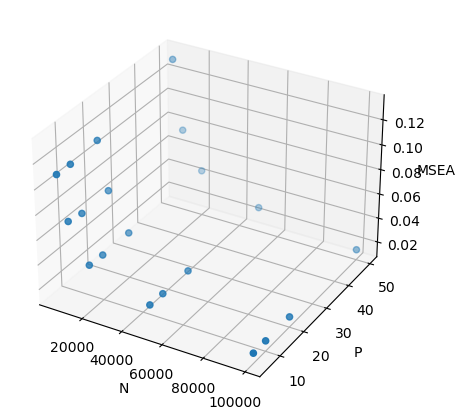

In [67]:
fig = plt.figure(figsize=(6, 4))  
ax = fig.add_subplot(projection='3d')
ax.scatter(s31mean.N, s31mean.P, s31mean.MSEA)
ax.set_xlabel('N')
ax.set_ylabel('P')
ax.set_zlabel('MSEA')
#ax.set_title('Simulation 3: 2 variables in mean - 1 variable in variance')

Text(0.5, 0, 'MSEA')

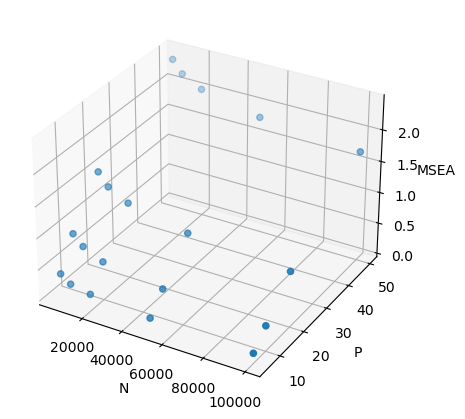

In [68]:
fig = plt.figure(figsize=(6, 4))  
ax = fig.add_subplot(projection='3d')
ax.scatter(s32mean.N, s32mean.P, s32mean.MSEA)
ax.set_xlabel('N')
ax.set_ylabel('P')
ax.set_zlabel('MSEA')
#ax.set_title('Simulation 3: 2 variables in mean - 1 variable in variance')

Text(0.5, 0, 'MSEV')

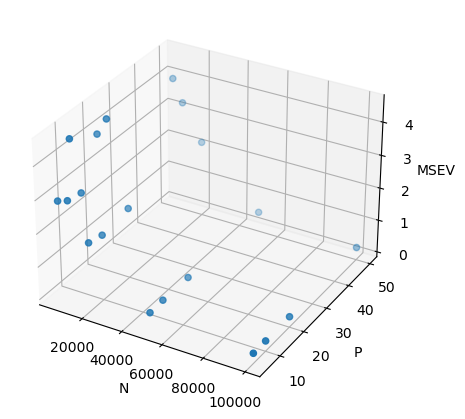

In [69]:
fig = plt.figure(figsize=(6, 4))  
ax = fig.add_subplot(projection='3d')
ax.scatter(s31mean.N, s31mean.P, s31mean.MSEV)
ax.set_xlabel('N')
ax.set_ylabel('P')
ax.set_zlabel('MSEV')
#ax.set_title('Simulation 3: 2 variables in mean - 1 variable in variance')

Text(0.5, 0, 'MSEV')

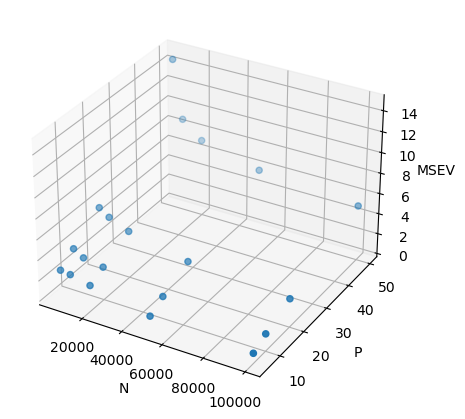

In [70]:
fig = plt.figure(figsize=(6, 4))  
ax = fig.add_subplot(projection='3d')
ax.scatter(s32mean.N, s32mean.P, s32mean.MSEV)
ax.set_xlabel('N')
ax.set_ylabel('P')
ax.set_zlabel('MSEV')
#ax.set_title('Simulation 3: 2 variables in mean - 1 variable in variance')

In [84]:
s41 = pd.read_csv('kk/med4.csv')
s42 = pd.read_csv('kk/med4_50.csv')
s41mean = s41.groupby(['N', 'P'])[['MSEA', 'MSEV']].mean().reset_index()
s42mean = s42.groupby(['N', 'P'])[['MSEA', 'MSEV']].mean().reset_index()

s43 = pd.concat([s41, s42])
s43mean = s43.groupby(['N', 'P'])[['MSEA', 'MSEV']].mean().reset_index()
s43.to_csv('mod4.csv')

In [85]:
s41 = pd.read_csv('kk/med4_no.csv')
s42 = pd.read_csv('kk/med4_no_50.csv')
s41mean = s41.groupby(['N', 'P'])[['MSEA', 'MSEV']].mean().reset_index()
s42mean = s42.groupby(['N', 'P'])[['MSEA', 'MSEV']].mean().reset_index()

s43 = pd.concat([s41, s42])
s43mean = s43.groupby(['N', 'P'])[['MSEA', 'MSEV']].mean().reset_index()
s43.to_csv('mod4_no.csv')

In [87]:
s41 = pd.read_csv('./mod4.csv')
s42 = pd.read_csv('./mod4_no.csv')
s41mean = s41.groupby(['N', 'P'])[['MSEA', 'MSEV']].mean().reset_index()
s42mean = s42.groupby(['N', 'P'])[['MSEA', 'MSEV']].mean().reset_index()

In [88]:
p5_1 = s41mean.loc[s41mean['P'] == 5, ['N', 'MSEA', 'MSEV']].reset_index(drop=True)
p10_1 = s41mean.loc[s41mean['P'] == 10, ['MSEA', 'MSEV']].reset_index(drop=True)
p20_1 = s41mean.loc[s41mean['P'] == 20, ['MSEA', 'MSEV']].reset_index(drop=True)
p50_1 = s41mean.loc[s41mean['P'] == 50, ['MSEA', 'MSEV']].reset_index(drop=True)

p5_2 = s42mean.loc[s42mean['P'] == 5, ['N', 'MSEA', 'MSEV']].reset_index(drop=True)
p10_2 = s42mean.loc[s42mean['P'] == 10, ['MSEA', 'MSEV']].reset_index(drop=True)
p20_2 = s42mean.loc[s42mean['P'] == 20, ['MSEA', 'MSEV']].reset_index(drop=True)
p50_2 = s42mean.loc[s42mean['P'] == 50, ['MSEA', 'MSEV']].reset_index(drop=True)

df1 = pd.concat([p5_1, p10_1, p20_1, p50_1], axis=1)
df1.index = pd.MultiIndex.from_tuples([
    ("FS", "1"), ("FS", "2"), ("FS", "3"), ("FS", "4"), ("FS", "5")
])

df2 = pd.concat([p5_2, p10_2, p20_2, p50_2], axis=1)
df2.index = pd.MultiIndex.from_tuples([
    ("FS", "1"), ("FS", "2"), ("FS", "3"), ("FS", "4"), ("FS", "5")
])

df = pd.concat([df1, df2], axis=0)
latex = df.style.format(precision=4).format_index(
    axis=1, formatter="${}$".format).hide(axis=0).to_latex(
        position='bt!',
        position_float="centering",
        hrules=False, 
        label="tab:med4", 
        column_format='c|c|cc|cc|cc|cc',
        caption="Performance evaluations in scenario 3 of the estimators $\overline{x}$ and $\hat{v}$ for the different K-NN graph settings described in the text with and without feature selection. We report the mean squared error averaging over 100 Monte Carlo simulations.",
)
print(latex)

\begin{table}[bt!]
\centering
\caption{Performance evaluations in scenario 3 of the estimators $\overline{x}$ and $\hat{v}$ for the different K-NN graph settings described in the text with and without feature selection. We report the mean squared error averaging over 100 Monte Carlo simulations.}
\label{tab:med4}
\begin{tabular}{c|c|cc|cc|cc|cc}
$N$ & $MSEA$ & $MSEV$ & $MSEA$ & $MSEV$ & $MSEA$ & $MSEV$ & $MSEA$ & $MSEV$ \\
5000 & 0.4492 & 4.8810 & 0.4748 & 5.7071 & 0.5487 & 6.4132 & 0.8646 & 8.2382 \\
10000 & 0.2070 & 4.3001 & 0.2001 & 4.5830 & 0.2002 & 5.2007 & 0.2037 & 5.6938 \\
20000 & 0.1375 & 4.0639 & 0.1347 & 4.5087 & 0.1361 & 4.7070 & 0.1350 & 5.0836 \\
50000 & 0.0815 & 2.0606 & 0.0806 & 2.1841 & 0.0808 & 2.1381 & 0.0806 & 2.4248 \\
100000 & 0.0581 & 0.6724 & 0.0586 & 0.6185 & 0.0589 & 0.6884 & 0.0583 & 0.8257 \\
5000 & 0.5957 & 4.8698 & 1.3052 & 6.4275 & 2.2609 & 11.2373 & 3.5751 & 17.7136 \\
10000 & 0.4200 & 3.9648 & 1.0572 & 5.7865 & 1.9844 & 8.6255 & 3.2899 & 16.4283 \\
2000

Text(0.5, 0, 'MSEA')

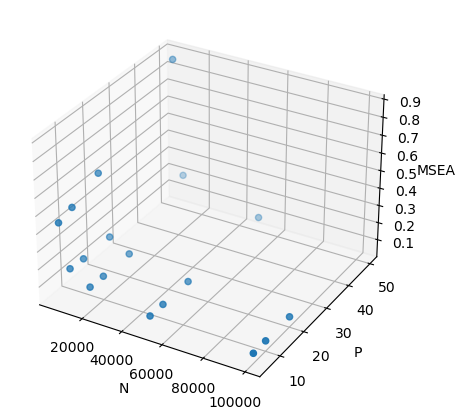

In [74]:
fig = plt.figure(figsize=(6, 4))  
ax = fig.add_subplot(projection='3d')
ax.scatter(s41mean.N, s41mean.P, s41mean.MSEA)
ax.set_xlabel('N')
ax.set_ylabel('P')
ax.set_zlabel('MSEA')
#ax.set_title('Simulation 4: 2 variables in mean - 0 variables in variance - No feature selection')

Text(0.5, 0, 'MSEA')

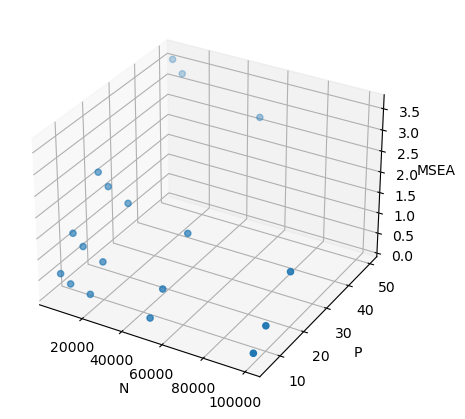

In [75]:
fig = plt.figure(figsize=(6, 4))  
ax = fig.add_subplot(projection='3d')
ax.scatter(s42mean.N, s42mean.P, s42mean.MSEA)
ax.set_xlabel('N')
ax.set_ylabel('P')
ax.set_zlabel('MSEA')
#ax.set_title('Simulation 4: 2 variables in mean - 0 variables in variance - No feature selection')

Text(0.5, 0, 'MSEV')

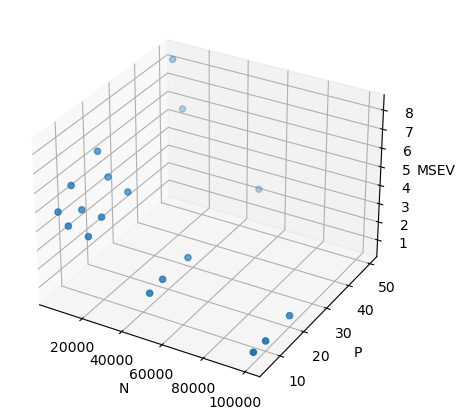

In [76]:
fig = plt.figure(figsize=(6, 4))  
ax = fig.add_subplot(projection='3d')
ax.scatter(s41mean.N, s41mean.P, s41mean.MSEV)
ax.set_xlabel('N')
ax.set_ylabel('P')
ax.set_zlabel('MSEV')
#ax.set_title('Simulation 4: 2 variables in mean - 0 variables in variance - No feature selection')

Text(0.5, 0, 'MSEV')

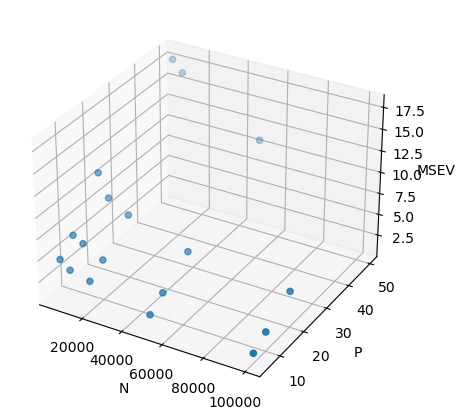

In [77]:
fig = plt.figure(figsize=(6, 4))  
ax = fig.add_subplot(projection='3d')
ax.scatter(s42mean.N, s42mean.P, s42mean.MSEV)
ax.set_xlabel('N')
ax.set_ylabel('P')
ax.set_zlabel('MSEV')
#ax.set_title('Simulation 4: 2 variables in mean - 0 variables in variance - No feature selection')